<a href="https://colab.research.google.com/github/Kommmi/Qaos/blob/main/01_GQS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Global state and environment-conditioned decomposition

The global state of a multibody system can be written as when focusing on a subsystem $S_a$.

$$
|\Psi_{SE}(t)\rangle
=\sum_{k=1}^{d_S}\sum_{j=1}^{d_E}
\psi_{kj}(t)\,
|s_k^{(a)}\rangle|e_j^{(\neq a)}\rangle.
$$

$$
|\Psi_{SE}(t)\rangle
=
\sum_{j=1}^{d_E}
\sqrt{\lambda_j^{E}(t)}
\,|\chi_j^{S_a}(t)\rangle
|e_j^{(\neq a)}\rangle .
$$
Here,
$$\lambda_j^{E}(t) = \sum_{k}|\psi_{kj}(t)|^2,
\quad
|\chi_j^{S_a}(t)\rangle
=
\frac{1}{\sqrt{\lambda_j^{E}(t)}}
\sum_{k}\psi_{kj}(t)\,|s_k^{(a)}\rangle.$$


### 2. Local state: density matrix

The reduced state of the subsystem is obtained by tracing out the environment:

$$
\rho^{S_a} =
\sum_{j=1}^{d_E}\lambda_j^E
|\chi_j^{S_a}\rangle\langle \chi_j^{S_a}|.
$$


### 3. Local state: geometric quantum state

Rather than viewing the reduced state solely as a density matrix, we adopt the **geometric quantum state (GQS)** representation.

Each conditional pure state defines a point in projective Hilbert space,

$$
|\chi_i^{S_a}\rangle →
\mathbf{Z}_i^{S_a}(t)
=\big[c_1^{(i)}(t):\cdots:c_d^{(i)}(t)\big]
\in\mathbb{C}P^{d_E-1}.
$$

The reduced state is represented as a probability measure,

$$
Q^{S_a}(Z,t)
=\sum_{j=1}^{d_E}\lambda_j^{E}(t)\,
\delta\!\left(Z-\mathbf{Z}_j^{S_a}(t)\right).
$$


The states $\{|\chi_j^{S_a}(t)\rangle\}$ are not generally orthogonal, and the weights $\{\lambda_j^{E}(t)\}$ are not eigenvalues of $\rho^{S_a}(t)$. Within the GQS framework, the pairs $\{\lambda_j^{E}(t),|\chi_j^{S_a}(t)\rangle\}$ define a probability distribution over subsystem pure states. This representation preserves the explicit correspondence between environment configurations and subsystem states


In [1]:
!rm -rf Qaos
# Clean slate
#!pip uninstall -y gqs
!git clone https://github.com/Kommmi/Qaos.git

# Move into the repo
%cd Qaos

# Install dependencies
!pip install -r requirements.txt

# Install the package in editable mode
!pip install -e .

from IPython.display import clear_output
clear_output()

print("Module ready to go :)")



Module ready to go :)


In [2]:

from gqs.states import Initial_state, rho_single_spin, Reduced_state_single_site, random_wavefunction, print_density_matrix, print_gqs_single_site, print_wavefunction
from gqs.plotsCompare import plot_gqs_and_density_matrix

Global State
(-0.0075+0.2394j) |000>      + (0.2204+0.4156j) |001>       + (0.4339+0.0400j) |010>       + (0.2009-0.1364j) |011>       +
(-0.4539+0.3100j) |100>      + (0.2381-0.0953j) |101>       + (0.0417-0.0939j) |110>       + (-0.1530-0.2658j) |111>     

 Reduced State - Density Matrix
rho_S =

                 |0>               |1>        
|0>             0.5275        0.1104+0.1303j  
|1>         0.1104-0.1303j        0.4725      

Trace = 1.0000
Hermitian check = True

 Reduced State - Geometric Quantum State
Geometric Quantum State Q^S
Subsystem site: 0
Subsystem dimension d_S = 2
Number of environment outcomes d_E = 4



,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|00>,(-0.013+0.399j) |0> + (-0.757+0.517j) |1>,0.359000
1,1,|01>,(0.411+0.776j) |0> + (0.444-0.178j) |1>,0.287000
2,2,|10>,(0.969+0.089j) |0> + (0.093-0.210j) |1>,0.200000
3,3,|11>,(0.514-0.349j) |0> + (-0.391-0.679j) |1>,0.153000


Reduced States Plot


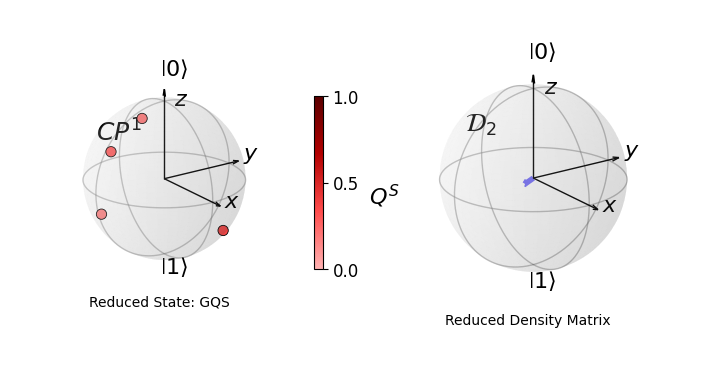

In [3]:
dhilbert = 2
nchain = 3
system_site = 0
psi = random_wavefunction(nchain)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)


Global State
(0.1905+0.2527j) |000>       + (0.1277-0.2153j) |001>       + (-0.0370+0.2793j) |010>      + (-0.3256-0.2481j) |011>      +
(-0.1479-0.1746j) |100>      + (-0.1283+0.3863j) |101>      + (-0.4183+0.2310j) |110>      + (0.3574-0.1270j) |111>      

 Reduced State - Density Matrix
rho_S =

                 |0>               |1>        
|0>             0.3809        0.0020+0.2682j  
|1>         0.0020-0.2682j        0.6191      

Trace = 1.0000
Hermitian check = True

 Reduced State - Geometric Quantum State
Geometric Quantum State Q^S
Subsystem site: 1
Subsystem dimension d_S = 2
Number of environment outcomes d_E = 4



,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|00>,(0.450+0.596j) |0> + (-0.087+0.659j) |1>,0.180000
1,1,|01>,(0.266-0.449j) |0> + (-0.679-0.517j) |1>,0.230000
2,2,|10>,(-0.279-0.330j) |0> + (-0.790+0.436j) |1>,0.281000
3,3,|11>,(-0.231+0.694j) |0> + (0.642-0.228j) |1>,0.310000


Reduced States Plot


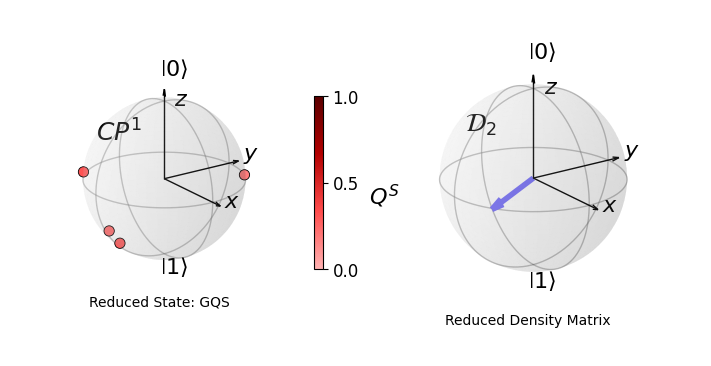

In [4]:
system_site = 1
psi = random_wavefunction(nchain)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)


Global State
(0.4136+0.3566j) |000>       + (0.1057-0.1679j) |001>       + (0.3213+0.1521j) |010>       + (0.1510+0.0052j) |011>       +
(-0.0568+0.4218j) |100>      + (-0.3312-0.1873j) |101>      + (0.1084+0.1163j) |110>       + (0.0667+0.3969j) |111>      

 Reduced State - Density Matrix
rho_S =

                 |0>               |1>        
|0>             0.6311        0.0263-0.0572j  
|1>         0.0263+0.0572j        0.3689      

Trace = 1.0000
Hermitian check = True

 Reduced State - Geometric Quantum State
Geometric Quantum State Q^S
Subsystem site: 2
Subsystem dimension d_S = 2
Number of environment outcomes d_E = 4



,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|00>,(0.712+0.614j) |0> + (0.182-0.289j) |1>,0.338000
1,1,|01>,(0.832+0.394j) |0> + (0.391+0.014j) |1>,0.149000
2,2,|10>,(-0.099+0.739j) |0> + (-0.580-0.328j) |1>,0.326000
3,3,|11>,(0.251+0.269j) |0> + (0.154+0.917j) |1>,0.187000


Reduced States Plot


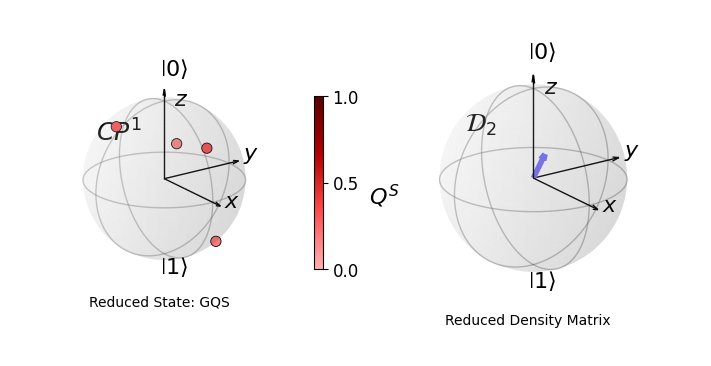

In [5]:
system_site = 2
psi = random_wavefunction(nchain)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)


Global State
(0.1331+0.1110j) |0000>      + (-0.0494+0.2072j) |0001>     + (0.1373-0.0686j) |0010>      + (-0.1407-0.0078j) |0011>     +
(0.1429+0.1509j) |0100>      + (0.1482-0.0721j) |0101>      + (0.2299-0.0613j) |0110>      + (0.2377-0.0517j) |0111>      +
(0.2551-0.2662j) |1000>      + (-0.0298-0.0471j) |1001>     + (-0.2678-0.4719j) |1010>     + (0.0179+0.3014j) |1011>      +
(0.0080+0.2260j) |1100>      + (0.0852-0.0144j) |1101>      + (-0.2818+0.1802j) |1110>     + (0.0044-0.0003j) |1111>     

 Reduced State - Density Matrix
rho_S =

                 |0>               |1>        
|0>             0.3049       -0.0390+0.1213j  
|1>        -0.0390-0.1213j        0.6951      

Trace = 1.0000
Hermitian check = True

 Reduced State - Geometric Quantum State
Geometric Quantum State Q^S
Subsystem site: 0
Subsystem dimension d_S = 2
Number of environment outcomes d_E = 8



,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|000>,(0.327+0.272j) |0> + (0.626-0.653j) |1>,0.166000
1,1,|001>,(-0.224+0.941j) |0> + (-0.135-0.214j) |1>,0.048000
2,2,|010>,(0.243-0.122j) |0> + (-0.475-0.837j) |1>,0.318000
3,3,|011>,(-0.422-0.023j) |0> + (0.054+0.905j) |1>,0.111000
4,4,|100>,(0.465+0.491j) |0> + (0.026+0.736j) |1>,0.094000
5,5,|101>,(0.796-0.387j) |0> + (0.458-0.077j) |1>,0.035000
6,6,|110>,(0.560-0.149j) |0> + (-0.687+0.439j) |1>,0.168000
7,7,|111>,(0.977-0.212j) |0> + (0.018-0.001j) |1>,0.059000


Reduced States Plot


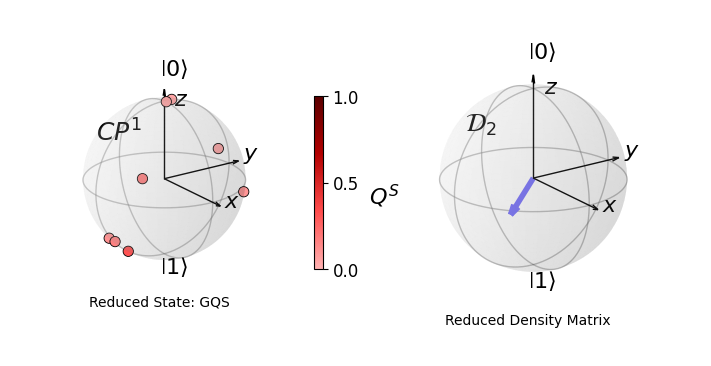

In [8]:
dhilbert = 2
nchain = 4
system_site = 0
psi = random_wavefunction(4)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)

Global State
(0.0385-0.2442j) |00000>     + (-0.1070-0.0423j) |00001>    + (-0.1565+0.0465j) |00010>    + (0.1054-0.3205j) |00011>     +
(0.0076+0.0933j) |00100>     + (-0.1550-0.1623j) |00101>    + (0.0180-0.1255j) |00110>     + (0.1761-0.2084j) |00111>     +
(-0.1780-0.0566j) |01000>    + (0.1009-0.0703j) |01001>     + (-0.0940-0.2649j) |01010>    + (0.0785-0.0976j) |01011>     +
(-0.0204-0.1027j) |01100>    + (0.1203-0.0096j) |01101>     + (-0.0088+0.1320j) |01110>    + (0.2164-0.0907j) |01111>     +
(0.1173+0.1127j) |10000>     + (-0.0866-0.1081j) |10001>    + (-0.0864+0.0624j) |10010>    + (-0.0049+0.0261j) |10011>    +
(0.1841+0.1636j) |10100>     + (-0.1196+0.1710j) |10101>    + (-0.0720-0.0771j) |10110>    + (-0.0672+0.0159j) |10111>    +
(0.0514-0.1509j) |11000>     + (0.0937-0.1655j) |11001>     + (0.1233-0.1238j) |11010>     + (-0.0110+0.0470j) |11011>    +
(-0.0299-0.0034j) |11100>    + (-0.2192+0.1112j) |11101>    + (-0.1182+0.1969j) |11110>    + (0.0148+0.0788j) |11111>  

,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|0000>,(0.130-0.825j) |0> + (0.396+0.381j) |1>,0.088000
1,1,|0001>,(-0.594-0.235j) |0> + (-0.481-0.600j) |1>,0.032000
2,2,|0010>,(-0.803+0.238j) |0> + (-0.443+0.320j) |1>,0.038000
3,3,|0011>,(0.312-0.947j) |0> + (-0.015+0.077j) |1>,0.115000
4,4,|0100>,(0.029+0.354j) |0> + (0.699+0.621j) |1>,0.069000
5,5,|0101>,(-0.506-0.530j) |0> + (-0.390+0.558j) |1>,0.094000
6,6,|0110>,(0.109-0.761j) |0> + (-0.436-0.468j) |1>,0.027000
7,7,|0111>,(0.626-0.741j) |0> + (-0.239+0.056j) |1>,0.079000
8,8,|1000>,(-0.725-0.231j) |0> + (0.209-0.615j) |1>,0.060000
9,9,|1001>,(0.445-0.311j) |0> + (0.414-0.731j) |1>,0.051000


Reduced States Plot


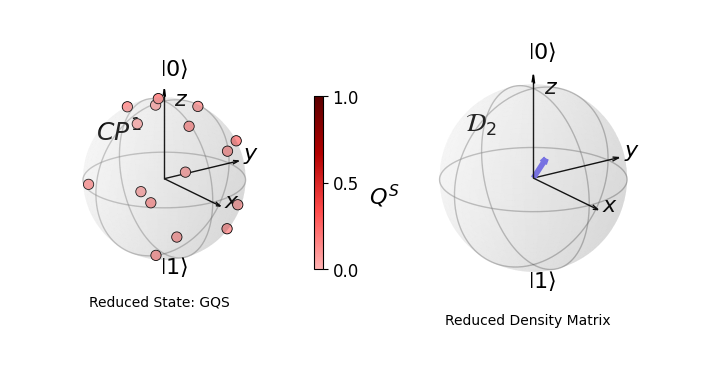

In [9]:
dhilbert = 2
nchain = 5
system_site = 0
psi = random_wavefunction(5)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)